# Data Science with Python Internship – Task 3
## Mini Exploratory Data Analysis (EDA) on the Titanic Dataset

**Goal:** Building on Task 2, this notebook performs a deeper EDA on the Titanic dataset:
- Better missing-value handling (imputation)
- `groupby`-based insights (Age Group, Embarkation Port, Family Size)
- More advanced, professional visualizations (histogram, correlation heatmap, bar plots)


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load the Dataset

Using the standard Titanic dataset (same source as Task 2).

In [2]:
df = pd.read_csv("titanic.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 3. Clean the Dataset

### 3.1 Check missing values before cleaning

In [4]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### 3.2 Fill missing `Age` with the mean

The task requires filling missing ages with the column mean (a simple, standard imputation strategy for EDA purposes).

In [5]:
df["Age"] = df["Age"].fillna(df["Age"].mean())


### 3.3 Handle missing `Embarked`

`Embarked` has a small number of missing values, so we fill them with the mode (most frequent port) rather than dropping the rows.

In [6]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])


### 3.4 Drop irrelevant columns

`Cabin` has too many missing values (~77%) to be useful, and `Name`, `Ticket`, `PassengerId` are identifiers that don't carry analytical signal for this EDA.

In [7]:
df.drop(columns=["Cabin", "Name", "Ticket", "PassengerId"], inplace=True)


### 3.5 Confirm the dataset is clean

In [8]:
df.isnull().sum()


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [9]:
df.describe(include="all")


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,891.000000,891.000000,891,891.000000,891.000000,891.000000,891.000000,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,646
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN
std,0.486592,0.836071,NaN,13.002015,1.102743,0.806057,49.693429,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN
25%,0.000000,2.000000,NaN,22.000000,0.000000,0.000000,7.910400,NaN
50%,0.000000,3.000000,NaN,29.699118,0.000000,0.000000,14.454200,NaN
75%,1.000000,3.000000,NaN,35.000000,1.000000,0.000000,31.000000,NaN


## 4. Feature Engineering

Create the two derived features needed for the analysis questions: `AgeGroup` and `FamilySize`.

In [10]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)

df["FamilySize"] = df["SibSp"] + df["Parch"]

df[["Age", "AgeGroup", "SibSp", "Parch", "FamilySize"]].head()


,Age,AgeGroup,SibSp,Parch,FamilySize
0,22.0,YoungAdult,1,0,1
1,38.0,Adult,1,0,1
2,26.0,YoungAdult,0,0,0
3,35.0,Adult,1,0,1
4,35.0,Adult,0,0,0


## 5. Analysis Questions (using `groupby`)

### 5.1 Survival rate by Age Group

In [11]:
survival_by_agegroup = df.groupby("AgeGroup", observed=True)["Survived"].mean().sort_values(ascending=False)
survival_by_agegroup


AgeGroup
Child         0.579710
Teen          0.428571
Adult         0.423237
Senior        0.343750
YoungAdult    0.331096
Name: Survived, dtype: float64

**Insight:** Children have the highest survival rate, consistent with the "women and children first" evacuation policy, while adults and seniors survived at lower rates.

### 5.2 Survival rate by Embarkation Port

In [12]:
survival_by_embarked = df.groupby("Embarked")["Survived"].mean().sort_values(ascending=False)
survival_by_embarked


Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64

**Insight:** Passengers who boarded at Cherbourg (C) had a noticeably higher survival rate than those from Queenstown (Q) or Southampton (S) — likely linked to the higher proportion of 1st-class passengers boarding at Cherbourg.

### 5.3 Survival rate by Family Size (SibSp + Parch)

In [13]:
survival_by_familysize = df.groupby("FamilySize")["Survived"].mean().sort_values(ascending=False)
survival_by_familysize


FamilySize
3     0.724138
2     0.578431
1     0.552795
6     0.333333
0     0.303538
4     0.200000
5     0.136364
7     0.000000
10    0.000000
Name: Survived, dtype: float64

**Insight:** Passengers traveling with a small family (1-3 relatives) had better survival odds than those traveling completely alone or with very large families (likely due to help boarding lifeboats vs. the difficulty of large groups staying together).

## 6. Visualizations

### 6.1 Age Distribution (Histogram)

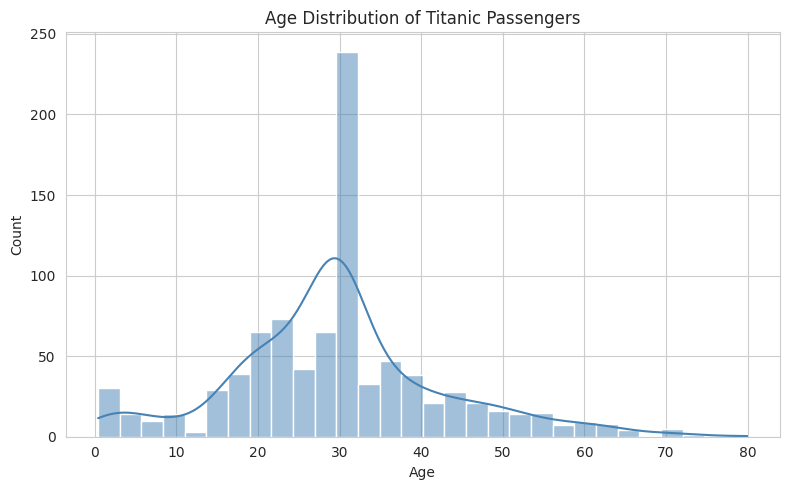

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### 6.2 Heatmap of Correlations

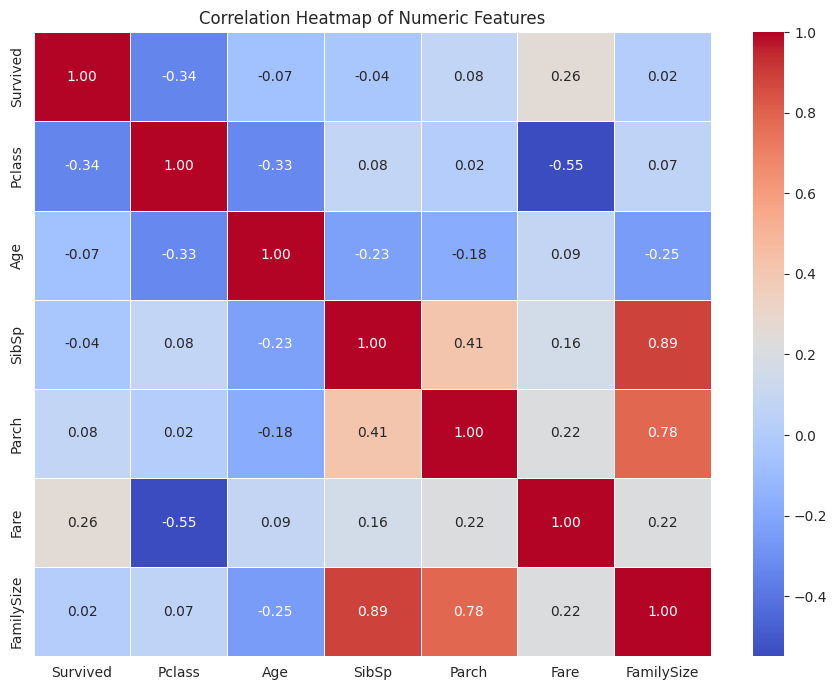

In [15]:
plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


### 6.3 Survival Rate by Family Size (Bar Plot)

/tmp/ipykernel_143/631554075.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="FamilySize", y="Survived", data=df, palette="viridis", errorbar=None)


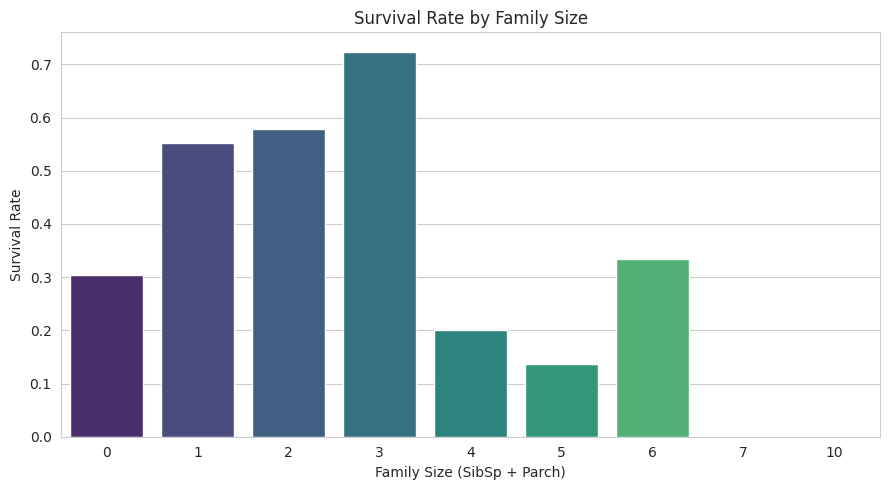

In [16]:
plt.figure(figsize=(9, 5))
sns.barplot(x="FamilySize", y="Survived", data=df, palette="viridis", errorbar=None)
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size (SibSp + Parch)")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()


### 6.4 Bonus: Survival Rate by Age Group and Embarkation Port

/tmp/ipykernel_143/3072999836.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AgeGroup", y="Survived", data=df, palette="mako", errorbar=None, ax=axes[0])
/tmp/ipykernel_143/3072999836.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Embarked", y="Survived", data=df, palette="flare", errorbar=None, ax=axes[1])


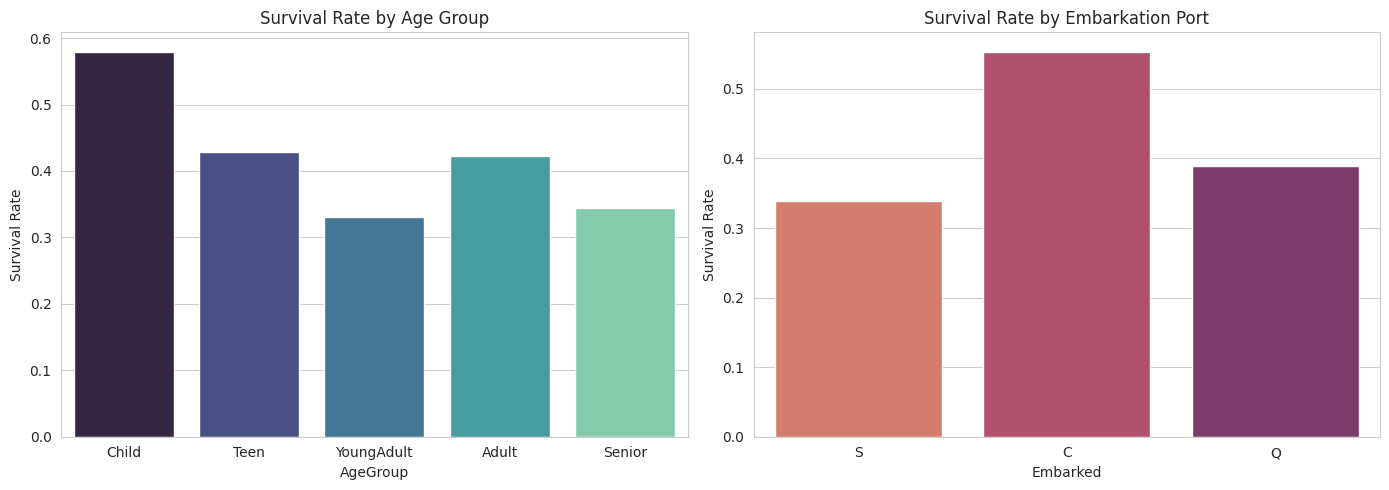

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x="AgeGroup", y="Survived", data=df, palette="mako", errorbar=None, ax=axes[0])
axes[0].set_title("Survival Rate by Age Group")
axes[0].set_ylabel("Survival Rate")

sns.barplot(x="Embarked", y="Survived", data=df, palette="flare", errorbar=None, ax=axes[1])
axes[1].set_title("Survival Rate by Embarkation Port")
axes[1].set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()


## 7. Summary of Insights

- **Age Group:** Children had the highest survival rate; survival generally declined with age.
- **Embarkation Port:** Passengers from Cherbourg (C) survived at a higher rate than those from Queenstown (Q) or Southampton (S).
- **Family Size:** Small families (1–3 members) survived more often than solo travelers or very large families.
- **Correlations:** `Pclass` and `Fare` show the strongest (negative/positive) correlation with `Survived` among numeric features — higher class (lower `Pclass` number) and higher fare are associated with better survival odds.

This mini-EDA builds on Task 2 by using better imputation (mean-filled `Age`, mode-filled `Embarked`), deeper `groupby` analysis, and more advanced/professional visualizations (KDE histogram, correlation heatmap, and comparative bar plots).
